<a href="https://colab.research.google.com/github/renishpatel-12/code-alpha-internship-ml-tasks/blob/main/CodeAlpha_CreditScoringModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"
df = pd.read_csv(url)

df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [2]:
!pip install scikit-learn pandas matplotlib seaborn

In [3]:
from sklearn.preprocessing import LabelEncoder

df = df.fillna("Unknown")

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,0,6,1,3,1169,4,1,4,3,2,...,2,67,1,1,2,1,1,1,1,1
1,2,48,3,3,5951,0,2,2,0,2,...,2,22,1,1,1,1,1,0,1,0
2,3,12,1,9,2096,0,3,2,3,2,...,2,49,1,1,1,3,2,0,1,1
3,0,42,3,7,7882,0,3,2,3,1,...,0,45,1,0,1,1,2,0,1,1
4,0,24,2,1,4870,0,2,3,3,2,...,3,53,1,0,2,1,2,0,1,0


In [5]:
X = df.drop("credit_risk", axis=1)
y = df["credit_risk"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(y_true, pred):
    print("Accuracy :", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred))
    print("Recall   :", recall_score(y_true, pred))
    print("F1 Score :", f1_score(y_true, pred))
    print("ROC-AUC  :", roc_auc_score(y_true, pred))

In [11]:
print("Logistic Regression")
evaluate(y_test, lr_pred)

print("\nDecision Tree")
evaluate(y_test, dt_pred)

print("\nRandom Forest")
evaluate(y_test, rf_pred)

Logistic Regression
Accuracy : 0.745
Precision: 0.78125
Recall   : 0.8865248226950354
F1 Score : 0.8305647840531561
ROC-AUC  : 0.6466522418559922

Decision Tree
Accuracy : 0.725
Precision: 0.8307692307692308
Recall   : 0.7659574468085106
F1 Score : 0.7970479704797048
ROC-AUC  : 0.6965380454381536

Random Forest
Accuracy : 0.765
Precision: 0.7865853658536586
Recall   : 0.9148936170212766
F1 Score : 0.8459016393442623
ROC-AUC  : 0.6608366390191129


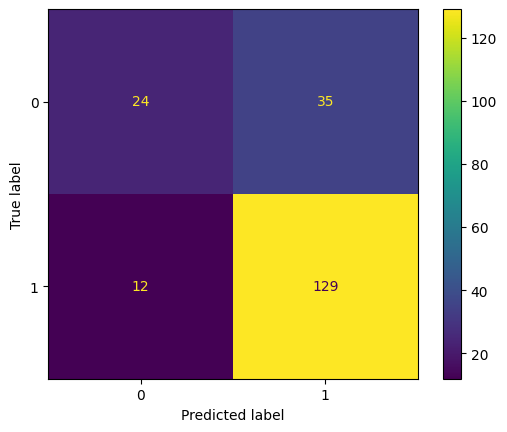

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)

plt.show()

In [13]:
import pickle

pickle.dump(rf, open("credit_model.pkl", "wb"))

In [14]:
from google.colab import files

files.download("credit_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>